In [1]:
import numpy as np
import matplotlib.pyplot as plt

# **El oscilador armónico**  
la ecuación del oscilador armónico  
$$
\ddot x + \omega_0^2 x=0
$$
hacemos $\tau= \omega_0 t$ y entonces $\frac{d}{dt}= \frac{d\tau}{dt}\frac{d}{d\tau}= \omega_0 \frac{d}{d\tau}$ y $\omega_0^2 \frac{d^2}{d\tau^2}$. Lo cual quiere decir
$$
x''+x=0
$$
donde la prima denota la derivada respecto a $\tau$. Hacemos $x$

In [3]:
def Euler(g,x0,t):
    h = t[1]-t[0]
    sol = np.zeros((len(x0), len(t)))
    sol[:,0] = x0
    return sol

In [4]:
def osc_old(x_vx):
    x= v_x[0]
    vx= x_vx[1]
    dx= vx
    dvx= -x
    return np.array([dx,dvx])

def osc(x_vx):
    return np.array([x_vx[1], -x_vx[0]])

In [6]:
x_ini = np.array([1,0])
t = np.arange(0,2*np.pi,0.01)
Euler(osc_old, x_ini,t)

array([[1., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

------------------------

In [8]:
import numpy as np
import matplotlib.pyplot as plt

In [9]:
def Euler(g,x0,t):
    h = t[1]-t[0]
    sol = np.zeros( (len(x0),len(t)) )
    sol[:,0] = x0
    for i in range(len(t)-1):
        sol[:,i+1] = sol[:,i] + h*g(sol[:,i],t[i])
    return sol

In [10]:
def osc(x_vx,t):
    return np.array( [ x_vx[1] , -x_vx[0] ] )

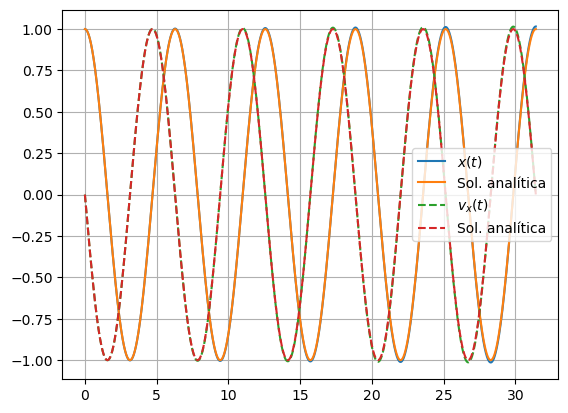

In [11]:
x_ini = np.array([1,0])
t = np.arange(0,10*np.pi,0.001)
sol = Euler(osc,x_ini,t)
plt.plot(t,sol[0,:],label=r'$x(t)$')
plt.plot(t,np.cos(t),label=r'Sol. analítica') # Solucion analitica de x
plt.plot(t,sol[1,:],'--',label=r'$v_x(t)$')
plt.plot(t,-np.sin(t),'--',label=r'Sol. analítica') # Solucion analitica de v_x
plt.grid(),plt.legend()
plt.show()

In [12]:
def RK2(g,x0,t):
    h = t[1]-t[0]
    sol = np.zeros( (len(x0),len(t)) )
    sol[:,0] = x0
    for i in range(len(t)-1):
        t_med = t[i] + 0.5*h
        sol_med = sol[:,i] + 0.5*h*g(sol[:,i],t[i])
        sol[:,i+1] = sol[:,i] + h*g(sol_med,t_med)
    return sol

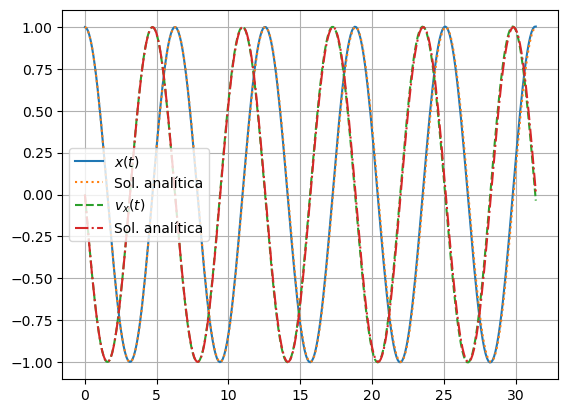

In [13]:
x_ini = np.array([1,0])
t = np.arange(0,10*np.pi,0.1)
sol = RK2(osc,x_ini,t)
plt.plot(t,sol[0,:],label=r'$x(t)$')
plt.plot(t,np.cos(t),':',label=r'Sol. analítica') # Solucion analitica de x
plt.plot(t,sol[1,:],'--',label=r'$v_x(t)$')
plt.plot(t,-np.sin(t),'-.',label=r'Sol. analítica') # Solucion analitica de v_x
plt.grid(),plt.legend()
plt.show()

In [14]:
a , b = np.array([[1,2],[3,4]]) , np.array([3,6])
a , b , a*b , np.dot(a,b)

(array([[1, 2],
        [3, 4]]),
 array([3, 6]),
 array([[ 3, 12],
        [ 9, 24]]),
 array([15, 33]))

In [15]:
def Euler_mejorado(g,x0,t,Jac):
    h = t[1]-t[0]
    sol = np.zeros( (len(x0),len(t)) )
    sol[:,0] = x0
    for i in range(len(t)-1):
        sol[:,i+1] = sol[:,i] + h*g(sol[:,i],t[i])
        sol[:,i+1] += 0.5*np.dot(Jac(sol[:,i],t[i]),g(sol[:,i],t[i]))*h**2
    return sol

In [16]:
def J_osc(x_vx,t):
    return np.array([[0,1],[-1,0]])

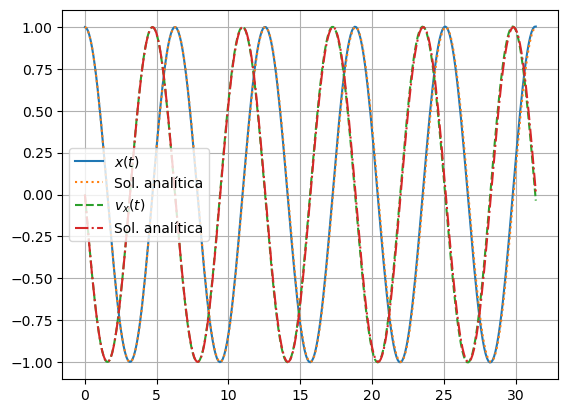

In [17]:
x_ini = np.array([1,0])
t = np.arange(0,10*np.pi,0.1)
sol = Euler_mejorado(osc,x_ini,t,J_osc)
plt.plot(t,sol[0,:],label=r'$x(t)$')
plt.plot(t,np.cos(t),':',label=r'Sol. analítica') # Solucion analitica de x
plt.plot(t,sol[1,:],'--',label=r'$v_x(t)$')
plt.plot(t,-np.sin(t),'-.',label=r'Sol. analítica') # Solucion analitica de v_x
plt.grid(),plt.legend()
plt.show()

----------------------------

Definiendo un problema de valor inicial como:  
$$
y'=f(x,y), y(x_0)=y_0
$$
Entonces el método RK4 para este problema está dado por la siguiente ecuación:
$$
y_{i+1}= y_i + \frac{1}{6}h(k_1 +2k_2 +2k_3 +k_4)
$$
Donde  
